# Viral Spread

This notebook uses AutoReduce to study models of viral spread at two levels of detail. We start with a three-state SIR model, then expand the same modeling idea into a six-state SEIRVD model with exposure, vaccination, and deaths. The goal is to show that a reduced model can be appropriate for one output and one parameter regime, but less appropriate after the ecological/population assumptions change. These can be explored using Autoreduce.


## The SIR model

The commonly used susceptible-infected-recovered model is

$$
\begin{aligned}
\dot{S} &= -\beta \frac{SI}{N}, \\
\dot{I} &= \beta \frac{SI}{N} - \gamma I, \\
\dot{R} &= \gamma I.
\end{aligned}
$$

The total population $N=S+I+R$ is conserved. This model is useful when the incubation period, vaccination, and mortality are not the focus of the question.

Let us create the model in AutoReduce directly by writing a Sympy ODE:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
from sympy import latex

from autoreduce import (
    System,
    load_ode_model,
    solve_ode,
    solve_sensitivity,
    solve_timescale_separation,
)

sir_states, sir_rhs, sir_params = load_ode_model(3, 3)
S, I, R = sir_states
beta, gamma, N = sir_params

sir_rhs[0] = -beta * S * I / N
sir_rhs[1] = beta * S * I / N - gamma * I
sir_rhs[2] = gamma * I

sir_population = 1000.0
sir_params_values = np.array([0.30, 0.08, sir_population])
sir_params_dict = dict(zip(sir_params, sir_params_values))
sir_x_init = np.array([990.0, 10.0, 0.0])
sir_C = np.eye(3).tolist()

sir_system = System(
    sir_states,
    sir_rhs,
    params_dict=sir_params_dict,
    C=sir_C,
    x_init=sir_x_init,
)

sir_timepoints = np.linspace(0.0, 160.0, 161)
sir_solution = solve_ode(sir_system, sir_timepoints).T

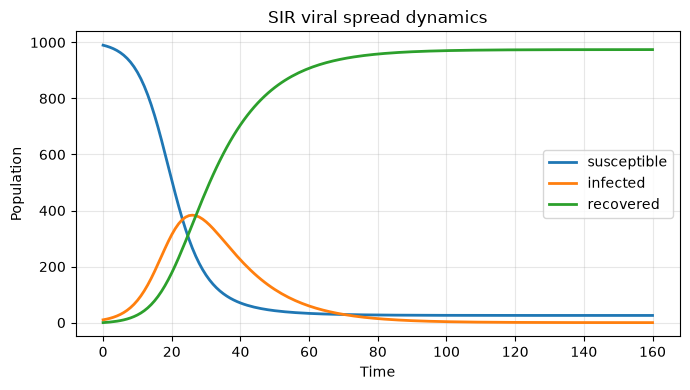

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

for label, trajectory in zip(
    ["susceptible", "infected", "recovered"],
    sir_solution,
):
    ax.plot(sir_timepoints, trajectory, linewidth=2, label=label)

ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.set_title("SIR viral spread dynamics")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## Add exposure, vaccination, and deaths

The SEIRVD model expands the SIR model by distinguishing people who have been exposed but are not yet infectious, people who leave the susceptible population through vaccination, and cumulative deaths.

$$
S=\text{susceptible},\quad
E=\text{exposed},\quad
I=\text{infected},\quad
R=\text{recovered},\quad
V=\text{vaccinated},\quad
D=\text{deceased}.
$$

The state vector and parameter vector are

$$
x =
\begin{bmatrix}
S & E & I & R & V & D
\end{bmatrix}^{T},
\qquad
\Theta =
\begin{bmatrix}
\beta & \sigma & \gamma & \nu & \mu & N
\end{bmatrix}^{T}.
$$

The governing equations are

$$
\begin{aligned}
\dot{S} &= -\frac{\beta S I}{N} - \nu S, \\
\dot{E} &= \frac{\beta S I}{N} - \sigma E, \\
\dot{I} &= \sigma E - \gamma I - \mu I, \\
\dot{R} &= \gamma I, \\
\dot{V} &= \nu S, \\
\dot{D} &= \mu I.
\end{aligned}
$$

The infected population is the first output we ask the reduced models to preserve:

$$
y=I.
$$


In [ ]:
seirvd_states, seirvd_rhs, seirvd_params = load_ode_model(6, 6)
S, E, I, R, V, D = seirvd_states
beta, sigma, gamma, nu, mu, N = seirvd_params

seirvd_rhs[0] = -beta * S * I / N - nu * S
seirvd_rhs[1] = beta * S * I / N - sigma * E
seirvd_rhs[2] = sigma * E - gamma * I - mu * I
seirvd_rhs[3] = gamma * I
seirvd_rhs[4] = nu * S
seirvd_rhs[5] = mu * I

seirvd_params_values = np.array([
    0.35,    # beta: transmission rate
    0.20,    # sigma: exposed-to-infected rate
    0.10,    # gamma: recovery rate
    0.01,    # nu: vaccination rate
    0.005,   # mu: mortality rate
    1000.0,  # N: total population scale
])
seirvd_params_dict = dict(zip(seirvd_params, seirvd_params_values))

seirvd_x_init = np.array([990.0, 9.0, 1.0, 0.0, 0.0, 0.0])
seirvd_C = np.zeros((1, len(seirvd_states)), dtype=int)
seirvd_C[0, 2] = 1

seirvd_system = System(
    seirvd_states,
    seirvd_rhs,
    params_dict=seirvd_params_dict,
    C=seirvd_C.tolist(),
    x_init=seirvd_x_init,
)

for state, label in zip(
    seirvd_states,
    ["susceptible", "exposed", "infected", "recovered", "vaccinated", "deceased"],
):
    print(f"{state}: {label}")

## Simulate the baseline SEIRVD model

The baseline parameter set has moderate transmission, a visible incubation period, slow vaccination, and low mortality. Plotting every state makes the compartment structure visible before any reduction is attempted.


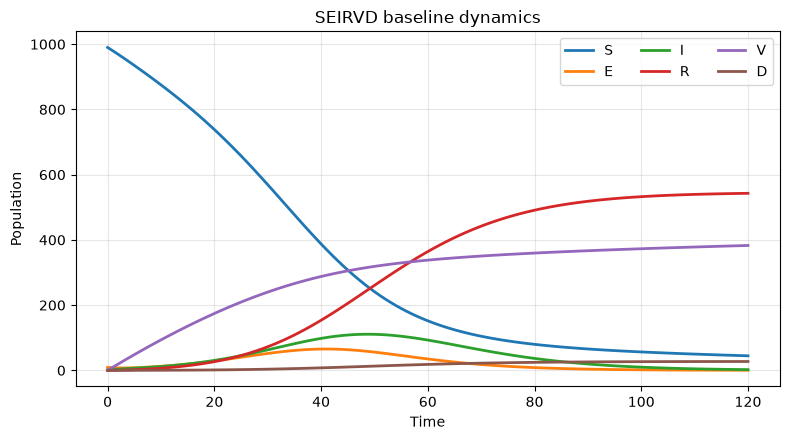

In [5]:
seirvd_timepoints = np.linspace(0.0, 120.0, 121)
seirvd_solution = solve_ode(seirvd_system, seirvd_timepoints).T

fig, ax = plt.subplots(figsize=(8, 4.5))

for label, trajectory in zip(
    ["S", "E", "I", "R", "V", "D"],
    seirvd_solution,
):
    ax.plot(seirvd_timepoints, trajectory, linewidth=2, label=label)

ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.set_title("SEIRVD baseline dynamics")
ax.grid(alpha=0.3)
ax.legend(ncol=3)
fig.tight_layout()
plt.show()


In [6]:
infected_baseline = seirvd_solution[2]

baseline_summary = {
    "peak infected": float(infected_baseline.max()),
    "time of infected peak": float(seirvd_timepoints[infected_baseline.argmax()]),
    "final susceptible": float(seirvd_solution[0, -1]),
    "final vaccinated": float(seirvd_solution[4, -1]),
    "final deceased": float(seirvd_solution[5, -1]),
}

baseline_summary


{'peak infected': 110.7496234300063,
 'time of infected peak': 49.0,
 'final susceptible': 44.60254674683289,
 'final vaccinated': 382.9135942777893,
 'final deceased': 27.14162836007647}

## Local sensitivity of the infected output

AutoReduce can also compute local sensitivities. Here we look at the normalized sensitivity of the infected state $I$ with respect to each SEIRVD parameter. This helps identify which biological rates matter most for the output before selecting reduced models.


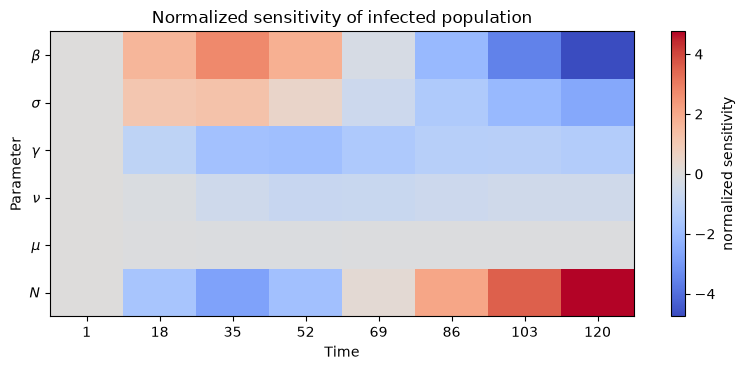

In [7]:
sensitivity_timepoints = np.linspace(1.0, 120.0, 8)
normalized_sensitivity = solve_sensitivity(
    seirvd_system,
    sensitivity_timepoints,
    normalize=True,
)

infected_sensitivity = normalized_sensitivity[:, :, 2]
sensitivity_scale = np.max(np.abs(infected_sensitivity))

fig, ax = plt.subplots(figsize=(8, 3.8))
image = ax.imshow(
    infected_sensitivity.T,
    aspect="auto",
    cmap="coolwarm",
    vmin=-sensitivity_scale,
    vmax=sensitivity_scale,
)

ax.set_xlabel("Time")
ax.set_ylabel("Parameter")
ax.set_title("Normalized sensitivity of infected population")
ax.set_xticks(range(len(sensitivity_timepoints)))
ax.set_xticklabels([f"{t:.0f}" for t in sensitivity_timepoints])
ax.set_yticks(range(len(seirvd_params)))
ax.set_yticklabels([r"$\beta$", r"$\sigma$", r"$\gamma$", r"$\nu$", r"$\mu$", r"$N$"])
fig.colorbar(image, ax=ax, label="normalized sensitivity")
fig.tight_layout()
plt.show()


## Reduce the SEIRVD model with visible state choices

The reductions below are chosen deliberately rather than generated through a large helper routine. The first model keeps the transmission core $(S,E,I)$ and removes cumulative states that do not feed back into infection. The second model keeps $(S,I,R,V,D)$ and collapses the exposed state, which is a stronger biological assumption because it removes the incubation stage.


In [8]:
reduction_timepoints_ode = np.linspace(0.0, 120.0, 121)
reduction_timepoints_ssm = np.linspace(0.0, 120.0, 6)

seirvd_core, core_fast_subsystem = solve_timescale_separation(
    seirvd_system,
    [S, E, I],
    timepoints_ode=reduction_timepoints_ode,
    timepoints_ssm=reduction_timepoints_ssm,
)

seirvd_direct_infection, direct_fast_subsystem = solve_timescale_separation(
    seirvd_system,
    [S, I, R, V, D],
    timepoints_ode=reduction_timepoints_ode,
    timepoints_ssm=reduction_timepoints_ssm,
)

seirvd_core.C = [[1 if state == I else 0 for state in seirvd_core.x]]
seirvd_direct_infection.C = [[1 if state == I else 0 for state in seirvd_direct_infection.x]]

seirvd_reduced_models = [
    ("transmission core: S, E, I", seirvd_core),
    ("direct infection: S, I, R, V, D", seirvd_direct_infection),
]


Successful solution obtained with states: [x0, x1, x2]!
Successful solution obtained with states: [x0, x2, x3, x4, x5]!


In [9]:
display(Math(r"\text{Full SEIRVD system: } " + latex(seirvd_rhs)))

for model_name, reduced_model in seirvd_reduced_models:
    print(model_name)
    print("retained states:", reduced_model.x)
    display(Math(r"\text{reduced equations: } " + latex(reduced_model.f)))
    print()


<IPython.core.display.Math object>

transmission core: S, E, I
retained states: [x0, x1, x2]


<IPython.core.display.Math object>


direct infection: S, I, R, V, D
retained states: [x0, x2, x3, x4, x5]


<IPython.core.display.Math object>

## Compare reduced infected trajectories

Because the output is $I$, a model can discard states such as $R$, $V$, and $D$ without hurting this particular comparison if those states do not feed back into infection. Collapsing the exposed state is different: it changes how quickly infection responds to contact between susceptible and infected populations.


In [ ]:
import pandas as pd

full_solution_for_reduction = solve_ode(seirvd_system, reduction_timepoints_ode).T
full_infected = full_solution_for_reduction[2]

reduction_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    full_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full SEIRVD model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = full_infected - reduced_infected

    reduction_summary.append({
        "model": model_name,
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "peak error": float(abs(full_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_xlabel("Time")
ax.set_ylabel("Infected population")
ax.set_title("Full and reduced infected trajectories")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

display(pd.DataFrame(reduction_summary))

## Change the parameter regime

The same reduced-state choices can behave differently when the biological regime changes. The cells below compare the full SEIRVD model with the two reduced models under higher transmission, faster vaccination, shorter incubation, and higher mortality.


In [ ]:
import pandas as pd

default_seirvd_params_dict = seirvd_system.params_dict.copy()

In [ ]:
scenario_name = "baseline"
scenario_params_dict = default_seirvd_params_dict.copy()
seirvd_system.set_param_dict(scenario_params_dict)

scenario_solution = solve_ode(seirvd_system, reduction_timepoints_ode).T
scenario_infected = scenario_solution[2]

baseline_scenario_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    scenario_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_model.set_param_dict(scenario_params_dict)
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = scenario_infected - reduced_infected

    baseline_scenario_summary.append({
        "model": model_name,
        "peak infected": float(scenario_infected.max()),
        "MAE": float(np.mean(np.abs(error))),
        "peak error": float(abs(scenario_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_title(scenario_name)
ax.set_xlabel("Time")
ax.set_ylabel("Infected")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(pd.DataFrame(baseline_scenario_summary))

In [ ]:
scenario_name = "higher transmission"
scenario_params_dict = default_seirvd_params_dict.copy()
scenario_params_dict[beta] = 0.55
seirvd_system.set_param_dict(scenario_params_dict)

scenario_solution = solve_ode(seirvd_system, reduction_timepoints_ode).T
scenario_infected = scenario_solution[2]

higher_transmission_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    scenario_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_model.set_param_dict(scenario_params_dict)
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = scenario_infected - reduced_infected

    higher_transmission_summary.append({
        "model": model_name,
        "peak infected": float(scenario_infected.max()),
        "MAE": float(np.mean(np.abs(error))),
        "peak error": float(abs(scenario_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_title(scenario_name)
ax.set_xlabel("Time")
ax.set_ylabel("Infected")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(pd.DataFrame(higher_transmission_summary))

In [ ]:
scenario_name = "faster vaccination"
scenario_params_dict = default_seirvd_params_dict.copy()
scenario_params_dict[nu] = 0.04
seirvd_system.set_param_dict(scenario_params_dict)

scenario_solution = solve_ode(seirvd_system, reduction_timepoints_ode).T
scenario_infected = scenario_solution[2]

faster_vaccination_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    scenario_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_model.set_param_dict(scenario_params_dict)
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = scenario_infected - reduced_infected

    faster_vaccination_summary.append({
        "model": model_name,
        "peak infected": float(scenario_infected.max()),
        "MAE": float(np.mean(np.abs(error))),
        "peak error": float(abs(scenario_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_title(scenario_name)
ax.set_xlabel("Time")
ax.set_ylabel("Infected")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(pd.DataFrame(faster_vaccination_summary))

In [ ]:
scenario_name = "shorter incubation"
scenario_params_dict = default_seirvd_params_dict.copy()
scenario_params_dict[sigma] = 0.50
seirvd_system.set_param_dict(scenario_params_dict)

scenario_solution = solve_ode(seirvd_system, reduction_timepoints_ode).T
scenario_infected = scenario_solution[2]

shorter_incubation_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    scenario_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_model.set_param_dict(scenario_params_dict)
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = scenario_infected - reduced_infected

    shorter_incubation_summary.append({
        "model": model_name,
        "peak infected": float(scenario_infected.max()),
        "MAE": float(np.mean(np.abs(error))),
        "peak error": float(abs(scenario_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_title(scenario_name)
ax.set_xlabel("Time")
ax.set_ylabel("Infected")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(pd.DataFrame(shorter_incubation_summary))

In [ ]:
scenario_name = "higher mortality"
scenario_params_dict = default_seirvd_params_dict.copy()
scenario_params_dict[mu] = 0.03
seirvd_system.set_param_dict(scenario_params_dict)

scenario_solution = solve_ode(seirvd_system, reduction_timepoints_ode).T
scenario_infected = scenario_solution[2]

higher_mortality_summary = []
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    reduction_timepoints_ode,
    scenario_infected,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in seirvd_reduced_models:
    reduced_model.set_param_dict(scenario_params_dict)
    reduced_solution = solve_ode(reduced_model, reduction_timepoints_ode).T
    reduced_infected = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    error = scenario_infected - reduced_infected

    higher_mortality_summary.append({
        "model": model_name,
        "peak infected": float(scenario_infected.max()),
        "MAE": float(np.mean(np.abs(error))),
        "peak error": float(abs(scenario_infected.max() - reduced_infected.max())),
    })

    ax.plot(
        reduction_timepoints_ode,
        reduced_infected,
        linewidth=2,
        label=model_name,
    )

ax.set_title(scenario_name)
ax.set_xlabel("Time")
ax.set_ylabel("Infected")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(pd.DataFrame(higher_mortality_summary))


The comparisons show that reduced-model quality depends on the output and on the regime being studied. The $(S,E,I)$ transmission-core model preserves the infected trajectory very closely because $R$, $V$, and $D$ are cumulative states that do not feed back into infection in this model. The direct-infection reduction is more aggressive because it collapses the exposed state, so its error changes with transmission, incubation, vaccination, and mortality rates.

This is the main modeling lesson: there is not one reduced viral-spread model that is best for every question. AutoReduce helps expose which state choices are compatible with the output and parameter regime that matter for the analysis.
